# Laboratorium 4: Algorytmy grupowania danych (k-means i DBSCAN)


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from ucimlrepo import fetch_ucirepo
from tqdm.auto import tqdm

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, rand_score,
)
from sklearn.metrics.cluster import contingency_matrix

# warnings.filterwarnings('ignore', category=UserWarning)
# warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')


## 0. Funkcje pomocnicze

Wszystkie miary i pomoce wizualne w jednym miejscu — używane w całym notebooku.


In [2]:
def purity(y_true, y_pred):
    '''Purity = sum_k max_j |C_k ∩ T_j| / N.  Punkty szumu DBSCAN (label=-1) liczone osobno (jeśli są).'''
    cm = contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(cm, axis=0)) / np.sum(cm)


def cluster_metrics(X, y_true, labels):
    '''Liczy 4 metryki. Silhouette/DB tylko gdy są ≥2 klastry (po wyłączeniu szumu).'''
    mask = labels != -1
    uniq = set(labels[mask]) if mask.any() else set()
    n_clusters = len(uniq)
    n_noise = int((labels == -1).sum())
    res = {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
    }
    if n_clusters >= 2 and mask.sum() > n_clusters:
        res['silhouette'] = silhouette_score(X[mask], labels[mask])
        res['davies_bouldin'] = davies_bouldin_score(X[mask], labels[mask])
    else:
        res['silhouette'] = np.nan
        res['davies_bouldin'] = np.nan
    if y_true is not None:
        res['ARI'] = adjusted_rand_score(y_true, labels)
        res['purity'] = purity(y_true, labels)
    return res


def plot_clusters_pca(X_scaled, labels, y_true, title, ax=None, pca=None):
    '''Scatter w PCA(2). Kolor = klaster, kształt = klasa GT. Szum (-1) jako szary X.'''
    if pca is None:
        pca = PCA(n_components=2).fit(X_scaled)
    Z = pca.transform(X_scaled)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    markers = ['o', 's', '^', 'D', 'P', 'X', 'v', '*']
    classes = sorted(np.unique(y_true)) if y_true is not None else [0]
    uniq = sorted(set(labels))
    palette = plt.cm.tab10(np.linspace(0, 1, max(len(uniq), 3)))
    color_map = {lbl: ('lightgray' if lbl == -1 else palette[i % 10]) for i, lbl in enumerate(uniq)}
    for cls_i, cls in enumerate(classes):
        m = markers[cls_i % len(markers)]
        for lbl in uniq:
            sel = (labels == lbl) & ((y_true == cls) if y_true is not None else np.ones_like(labels, bool))
            if sel.any():
                ax.scatter(Z[sel, 0], Z[sel, 1],
                           c=[color_map[lbl]], marker=('x' if lbl == -1 else m),
                           s=40, edgecolors='k', linewidths=0.3, alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    return pca


def class_histogram(y, title):
    vc = pd.Series(y).value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(7, 3.5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(vc)))
    bars = ax.bar(vc.index.astype(str), vc.values, color=colors, edgecolor='k')
    for b, v in zip(bars, vc.values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.3, str(v), ha='center', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('liczność')
    plt.tight_layout()
    plt.show()


## 1. Sanity check — IRIS

Zbiór IRIS służy tylko do weryfikacji, że pipeline (skalowanie → klasteryzacja → metryki → wizualizacja) działa poprawnie.
**Normalizacja danych** jest tu (i dalej) konieczna: zarówno k-means (odległości euklidesowe), jak i DBSCAN (sąsiedztwa o promieniu `eps`) są wrażliwe na skalę cech.


IRIS: (150, 4), klasy: [0 1 2]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.0000,150.0000,150.0000,150.0000
mean,5.8430,3.0570,3.7580,1.1990
std,0.8280,0.4360,1.7650,0.7620
min,4.3000,2.0000,1.0000,0.1000
25%,5.1000,2.8000,1.6000,0.3000
50%,5.8000,3.0000,4.3500,1.3000
75%,6.4000,3.3000,5.1000,1.8000
max,7.9000,4.4000,6.9000,2.5000


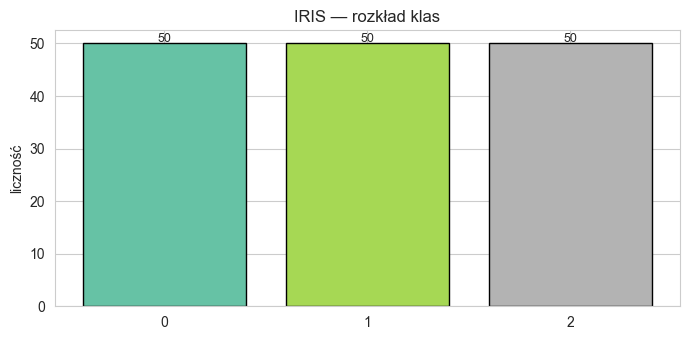

In [3]:
iris = load_iris()
X_iris_raw = iris.data
y_iris = iris.target
feat_iris = iris.feature_names

X_iris = StandardScaler().fit_transform(X_iris_raw)
print(f'IRIS: {X_iris.shape}, klasy: {np.unique(y_iris)}')
display(pd.DataFrame(X_iris_raw, columns=feat_iris).describe().round(3))
class_histogram(y_iris, 'IRIS — rozkład klas')


Sanity-check KMeans(k=3) na IRIS:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
0,3,0,0.4599,0.8336,0.6201,0.8333


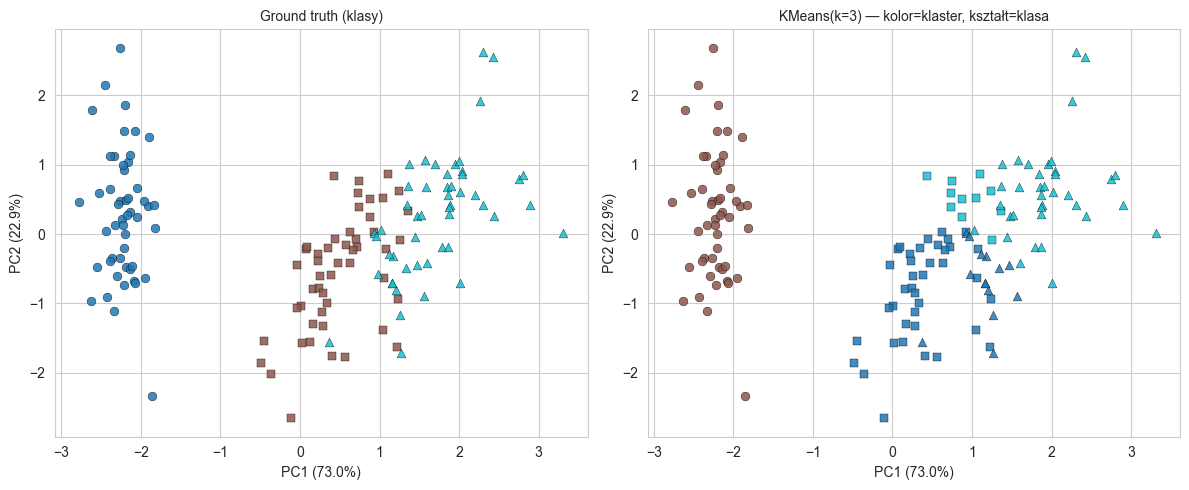

In [4]:
km_iris = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_iris)
m = cluster_metrics(X_iris, y_iris, km_iris.labels_)
print('Sanity-check KMeans(k=3) na IRIS:')
display(pd.DataFrame([m]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_clusters_pca(X_iris, y_iris, y_iris, 'Ground truth (klasy)', ax=axes[0])
plot_clusters_pca(X_iris, km_iris.labels_, y_iris, 'KMeans(k=3) — kolor=klaster, kształt=klasa', ax=axes[1])
plt.tight_layout()
plt.show()


## 2. Wczytanie zbiorów SEEDS i GLASS


SEEDS: X=(210, 7), klasy=[1 2 3]


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
count,210.0000,210.0000,210.0000,210.0000,210.0000,210.0000,210.0000
mean,14.8480,14.5590,0.8710,5.6290,3.2590,3.7000,5.4080
std,2.9100,1.3060,0.0240,0.4430,0.3780,1.5040,0.4910
min,10.5900,12.4100,0.8080,4.8990,2.6300,0.7650,4.5190
25%,12.2700,13.4500,0.8570,5.2620,2.9440,2.5620,5.0450
50%,14.3550,14.3200,0.8730,5.5240,3.2370,3.5990,5.2230
75%,17.3050,15.7150,0.8880,5.9800,3.5620,4.7690,5.8770
max,21.1800,17.2500,0.9180,6.6750,4.0330,8.4560,6.5500


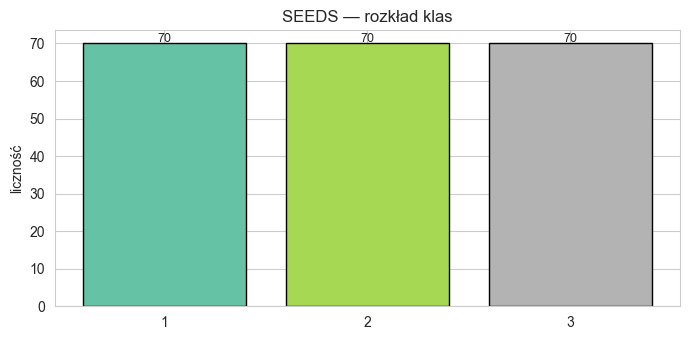

In [5]:
import os, urllib.request
SEEDS_PATH = 'data/seeds_dataset.txt'
SEEDS_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'
if not os.path.exists(SEEDS_PATH):
    os.makedirs(os.path.dirname(SEEDS_PATH), exist_ok=True)
    urllib.request.urlretrieve(SEEDS_URL, SEEDS_PATH)
feat_seeds = ['area', 'perimeter', 'compactness', 'kernel_length',
              'kernel_width', 'asymmetry', 'groove_length']
seeds_df = pd.read_csv(SEEDS_PATH, sep=r'\s+', header=None,
                       names=feat_seeds + ['class'])
X_seeds_raw = seeds_df[feat_seeds].values
y_seeds = seeds_df['class'].values
print(f'SEEDS: X={X_seeds_raw.shape}, klasy={np.unique(y_seeds)}')
display(seeds_df[feat_seeds].describe().round(3))
class_histogram(y_seeds, 'SEEDS — rozkład klas')


GLASS: X=(214, 9), klasy=[1 2 3 5 6 7]


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000
mean,1.5180,13.4080,2.6850,1.4450,72.6510,0.4970,8.9570,0.1750,0.0570
std,0.0030,0.8170,1.4420,0.4990,0.7750,0.6520,1.4230,0.4970,0.0970
min,1.5110,10.7300,0.0000,0.2900,69.8100,0.0000,5.4300,0.0000,0.0000
25%,1.5170,12.9080,2.1150,1.1900,72.2800,0.1220,8.2400,0.0000,0.0000
50%,1.5180,13.3000,3.4800,1.3600,72.7900,0.5550,8.6000,0.0000,0.0000
75%,1.5190,13.8250,3.6000,1.6300,73.0880,0.6100,9.1720,0.0000,0.1000
max,1.5340,17.3800,4.4900,3.5000,75.4100,6.2100,16.1900,3.1500,0.5100


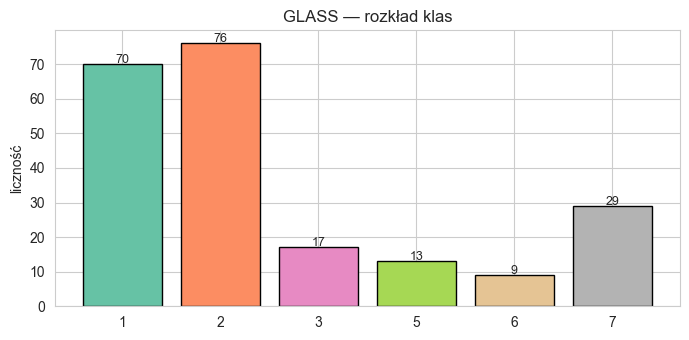

In [6]:
glass = fetch_ucirepo(id=42)
X_glass_raw = glass.data.features.values
y_glass = glass.data.targets.values.ravel()
feat_glass = list(glass.data.features.columns)
print(f'GLASS: X={X_glass_raw.shape}, klasy={np.unique(y_glass)}')
display(glass.data.features.describe().round(3))
class_histogram(y_glass, 'GLASS — rozkład klas')


In [7]:
X_seeds = StandardScaler().fit_transform(X_seeds_raw)
X_glass = StandardScaler().fit_transform(X_glass_raw)

DATASETS = {
    'SEEDS': (X_seeds, y_seeds, len(np.unique(y_seeds))),
    'GLASS': (X_glass, y_glass, len(np.unique(y_glass))),
}
for name, (X, y, k) in DATASETS.items():
    print(f'{name}: n={X.shape[0]}, d={X.shape[1]}, #klas={k}')


SEEDS: n=210, d=7, #klas=3
GLASS: n=214, d=9, #klas=6


## 3. K-means — sweep hiperparametrów

Badamy 3 parametry: `n_clusters`, `n_init`, `max_iter`. Dla każdego zbioru osobne sweepy, wykresy i tabela.


### 3.1 `n_clusters` — liczba klastrów

Sprawdzamy najpierw na IRIS (oczekujemy k=3), potem dla SEEDS/GLASS porównujemy 4 metryki + inercję (elbow).


In [8]:
def sweep_n_clusters(X, y, k_range, n_init=10):
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=n_init, random_state=0).fit(X)
        m = cluster_metrics(X, y, km.labels_)
        m['k'] = k
        m['inertia'] = km.inertia_
        rows.append(m)
    return pd.DataFrame(rows).set_index('k')


k_range = list(range(2, 11))
res_iris_k = sweep_n_clusters(X_iris, y_iris, k_range)
print('IRIS — sweep n_clusters:')
display(res_iris_k.round(4))


IRIS — sweep n_clusters:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity,inertia
k,,,,,,,
2,2,0,0.5818,0.5933,0.5681,0.6667,222.3617
3,3,0,0.4599,0.8336,0.6201,0.8333,139.8205
4,4,0,0.3869,0.8698,0.4728,0.8333,114.0925
5,5,0,0.3455,0.9452,0.4205,0.8333,90.8076
6,6,0,0.3257,1.0519,0.3563,0.8267,80.0225
7,7,0,0.3323,1.0654,0.4088,0.9200,71.6126
8,8,0,0.3449,0.8870,0.3136,0.8267,62.8661
9,9,0,0.3400,0.9608,0.3768,0.9600,55.5171
10,10,0,0.3486,0.8959,0.3323,0.9467,47.2637


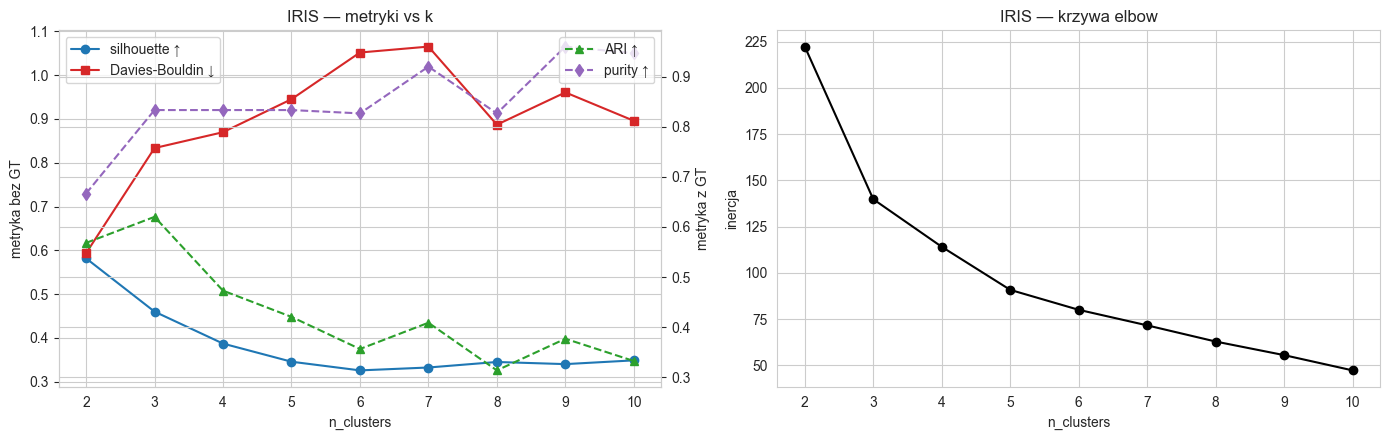

In [9]:
def plot_k_sweep(df, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    ax = axes[0]
    ax.plot(df.index, df['silhouette'], 'o-', label='silhouette ↑', color='tab:blue')
    ax.plot(df.index, df['davies_bouldin'], 's-', label='Davies-Bouldin ↓', color='tab:red')
    ax.set_xlabel('n_clusters'); ax.set_ylabel('metryka bez GT')
    ax.legend(loc='upper left')
    if 'ARI' in df.columns:
        ax2 = ax.twinx()
        ax2.plot(df.index, df['ARI'], '^--', label='ARI ↑', color='tab:green')
        ax2.plot(df.index, df['purity'], 'd--', label='purity ↑', color='tab:purple')
        ax2.set_ylabel('metryka z GT')
        ax2.legend(loc='upper right')
    axes[0].set_title(f'{title} — metryki vs k')
    axes[1].plot(df.index, df['inertia'], 'o-', color='black')
    axes[1].set_xlabel('n_clusters'); axes[1].set_ylabel('inercja')
    axes[1].set_title(f'{title} — krzywa elbow')
    plt.tight_layout(); plt.show()


plot_k_sweep(res_iris_k, 'IRIS')


SEEDS — sweep n_clusters:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity,inertia
k,,,,,,,
2,2,0,0.4658,0.7969,0.4805,0.6571,659.1718
3,3,0,0.4007,0.9279,0.7733,0.9190,430.6590
4,4,0,0.3292,1.0629,0.6388,0.8905,371.6531
5,5,0,0.2812,1.2160,0.5586,0.8714,327.7228
6,6,0,0.2865,1.1273,0.4984,0.8810,289.2202
7,7,0,0.2675,1.2089,0.3932,0.8667,263.8064
8,8,0,0.2509,1.2608,0.3311,0.8905,240.7678
9,9,0,0.2499,1.1793,0.3017,0.9048,224.8903
10,10,0,0.2386,1.1850,0.2822,0.8810,208.6432


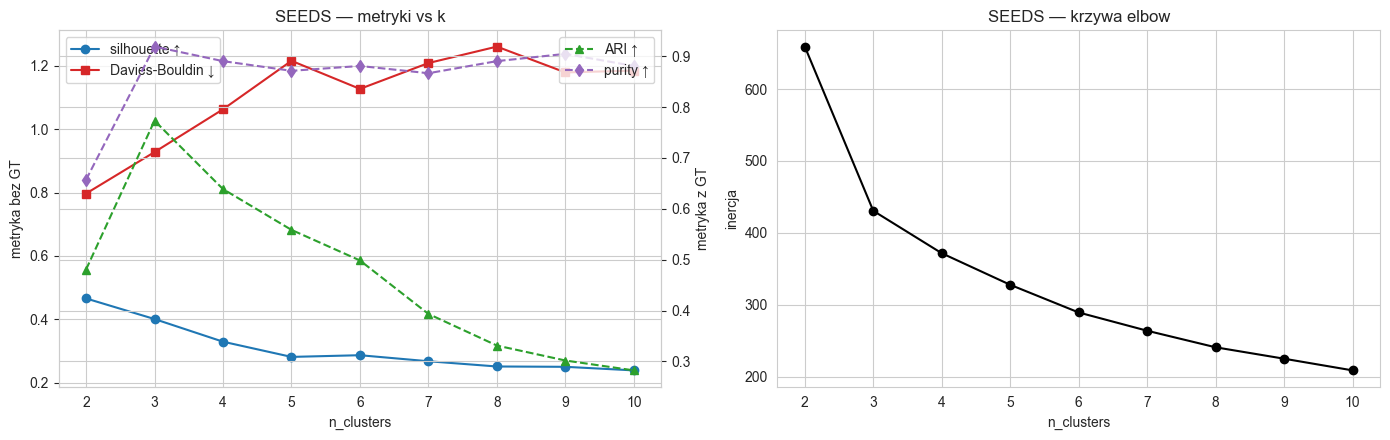

GLASS — sweep n_clusters:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity,inertia
k,,,,,,,
2,2,0,0.4475,1.3783,0.1930,0.4720,1526.2794
3,3,0,0.3672,1.3602,0.1889,0.4766,1240.5858
4,4,0,0.3910,1.0722,0.1987,0.4860,1036.5917
5,5,0,0.3219,1.0557,0.2398,0.5607,888.3197
6,6,0,0.3213,0.9901,0.1719,0.5561,766.5659
7,7,0,0.3375,1.0354,0.1793,0.5514,690.7538
8,8,0,0.3421,0.9307,0.2009,0.5794,631.1724
9,9,0,0.3419,1.0956,0.1688,0.5841,586.5241
10,10,0,0.3562,0.9513,0.2046,0.6168,521.1382


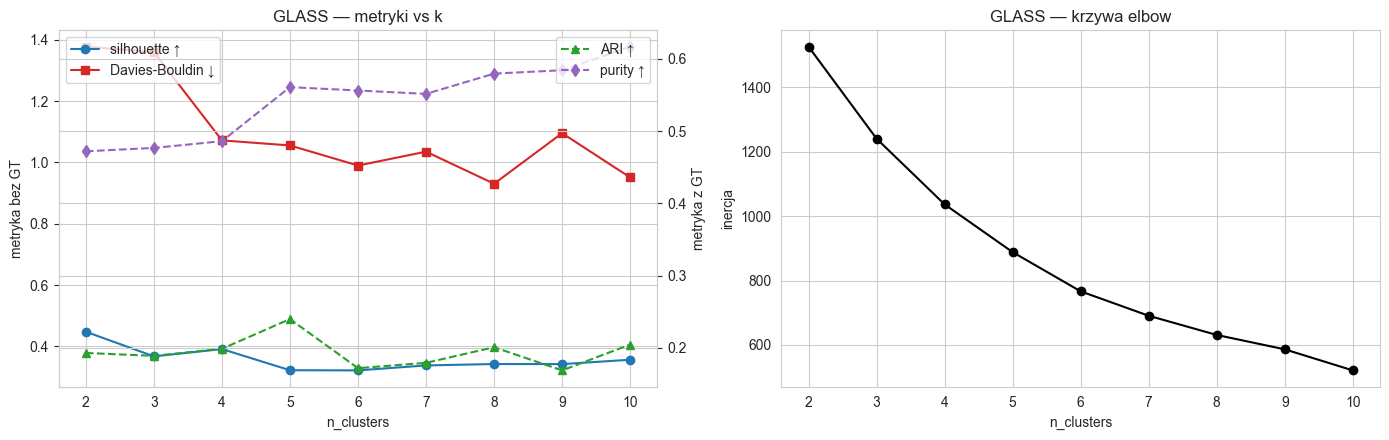

In [10]:
res_seeds_k = sweep_n_clusters(X_seeds, y_seeds, k_range)
res_glass_k = sweep_n_clusters(X_glass, y_glass, k_range)
print('SEEDS — sweep n_clusters:'); display(res_seeds_k.round(4))
plot_k_sweep(res_seeds_k, 'SEEDS')
print('GLASS — sweep n_clusters:'); display(res_glass_k.round(4))
plot_k_sweep(res_glass_k, 'GLASS')


### 3.2 `n_init` — liczba restartów

Powtarzamy uczenie 30 razy z różnymi `random_state`, aby pokazać jak `n_init` redukuje wariancję wyniku (k-means startuje od losowych centroidów).


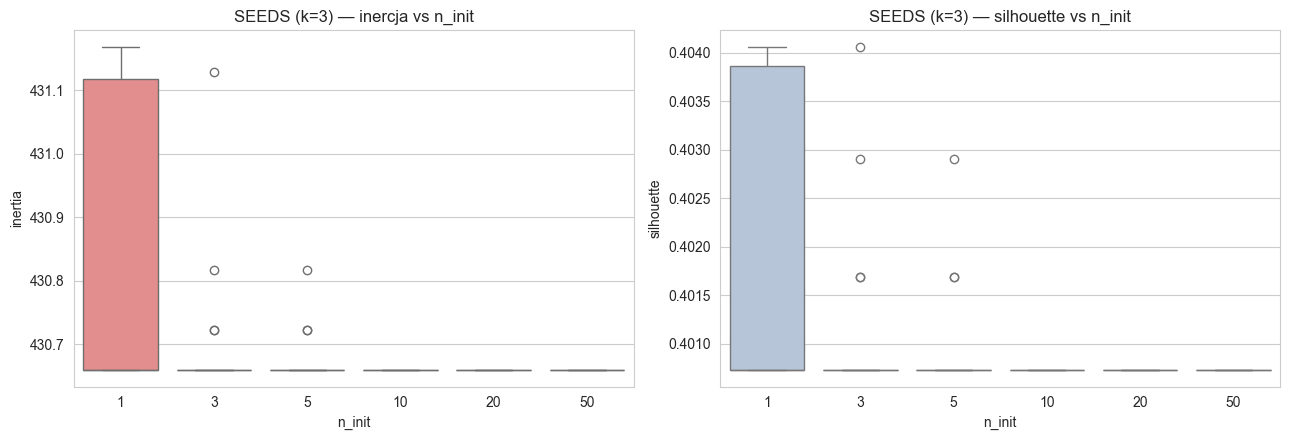

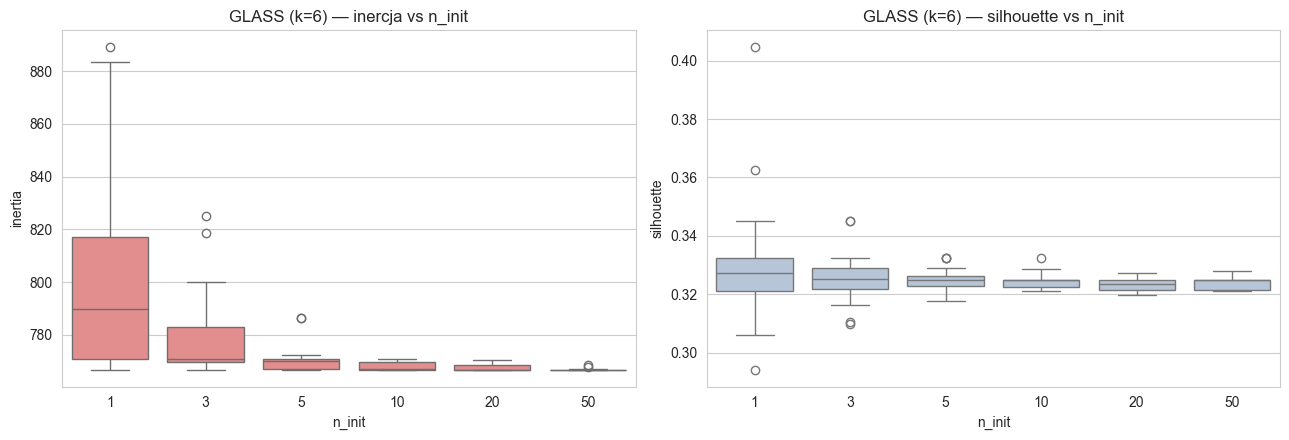

In [11]:
def sweep_n_init(X, y, k, n_init_values, n_repeats=30):
    rows = []
    for ni in n_init_values:
        for rep in range(n_repeats):
            km = KMeans(n_clusters=k, n_init=ni, max_iter=300, random_state=rep).fit(X)
            rows.append({'n_init': ni, 'rep': rep,
                         'inertia': km.inertia_,
                         'silhouette': silhouette_score(X, km.labels_)})
    return pd.DataFrame(rows)


n_init_vals = [1, 3, 5, 10, 20, 50]
df_ni_seeds = sweep_n_init(X_seeds, y_seeds, 3, n_init_vals)
df_ni_glass = sweep_n_init(X_glass, y_glass, 6, n_init_vals)


def plot_ninit(df, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.boxplot(data=df, x='n_init', y='inertia', ax=axes[0], color='lightcoral')
    axes[0].set_title(f'{title} — inercja vs n_init')
    sns.boxplot(data=df, x='n_init', y='silhouette', ax=axes[1], color='lightsteelblue')
    axes[1].set_title(f'{title} — silhouette vs n_init')
    plt.tight_layout(); plt.show()


plot_ninit(df_ni_seeds, 'SEEDS (k=3)')
plot_ninit(df_ni_glass, 'GLASS (k=6)')


### 3.3 `max_iter` — maksymalna liczba iteracji


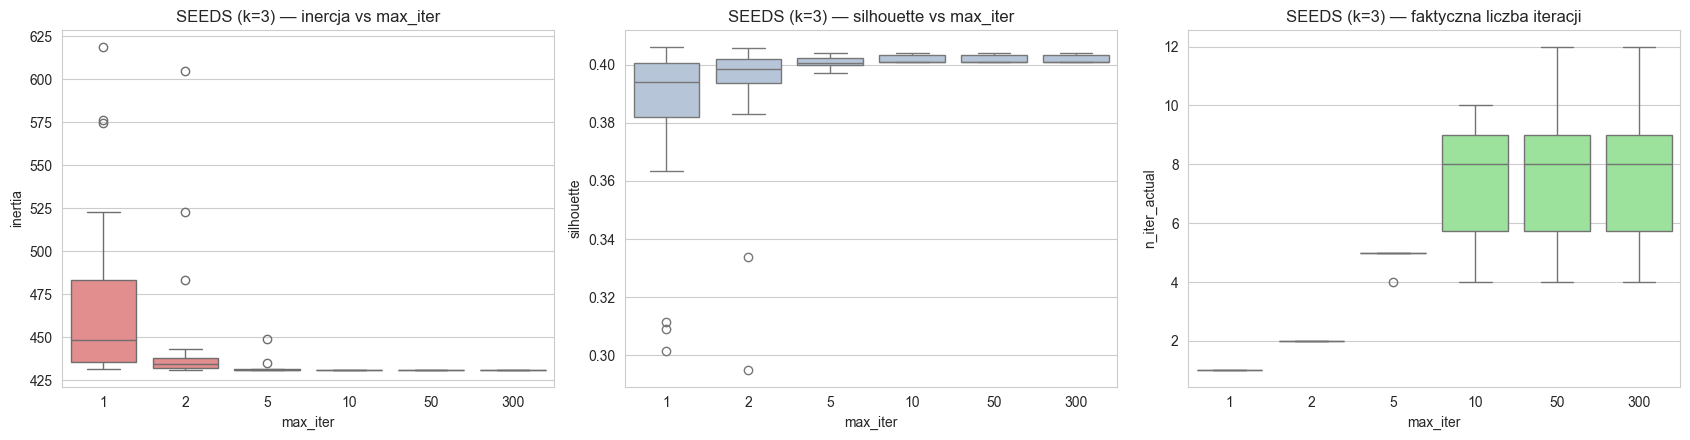

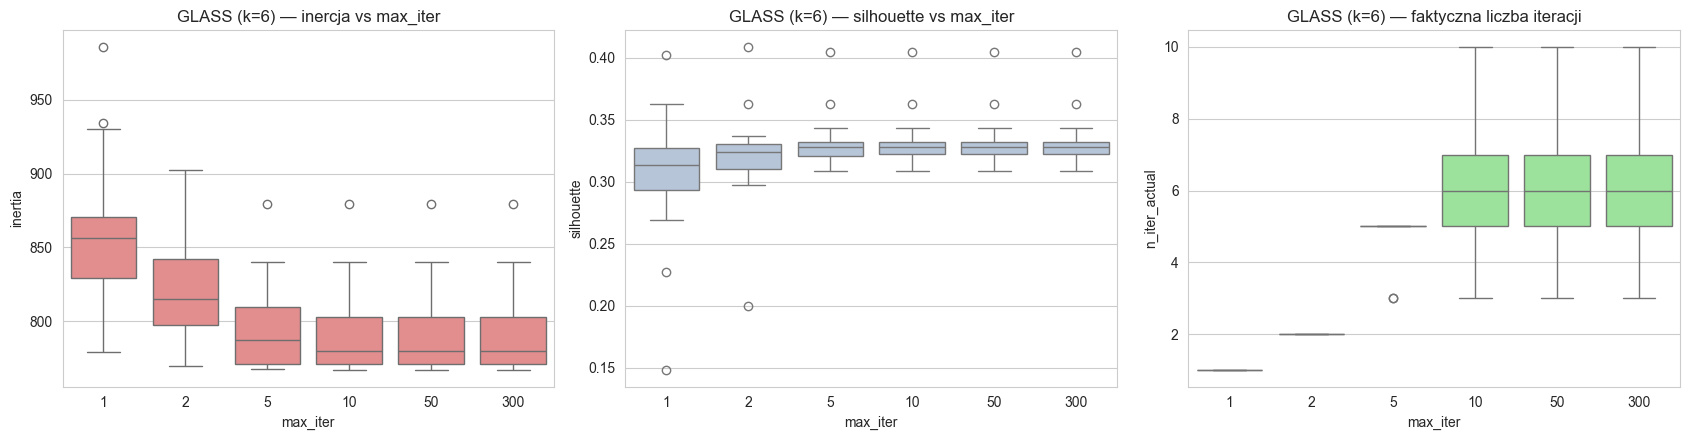

Mediana faktycznych iteracji (n_init=1):
  SEEDS: {1: 1.0, 2: 2.0, 5: 5.0, 10: 8.0, 50: 8.0, 300: 8.0}
  GLASS: {1: 1.0, 2: 2.0, 5: 5.0, 10: 6.0, 50: 6.0, 300: 6.0}


In [12]:
def sweep_max_iter(X, y, k, mi_values, n_repeats=20):
    rows = []
    for mi in mi_values:
        for rep in range(n_repeats):
            km = KMeans(n_clusters=k, n_init=1, max_iter=mi, random_state=rep).fit(X)
            rows.append({'max_iter': mi, 'rep': rep,
                         'inertia': km.inertia_,
                         'silhouette': silhouette_score(X, km.labels_),
                         'n_iter_actual': km.n_iter_})
    return pd.DataFrame(rows)


mi_vals = [1, 2, 5, 10, 50, 300]
df_mi_seeds = sweep_max_iter(X_seeds, y_seeds, 3, mi_vals)
df_mi_glass = sweep_max_iter(X_glass, y_glass, 6, mi_vals)


def plot_maxiter(df, title):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    sns.boxplot(data=df, x='max_iter', y='inertia', ax=axes[0], color='lightcoral')
    axes[0].set_title(f'{title} — inercja vs max_iter')
    sns.boxplot(data=df, x='max_iter', y='silhouette', ax=axes[1], color='lightsteelblue')
    axes[1].set_title(f'{title} — silhouette vs max_iter')
    sns.boxplot(data=df, x='max_iter', y='n_iter_actual', ax=axes[2], color='lightgreen')
    axes[2].set_title(f'{title} — faktyczna liczba iteracji')
    plt.tight_layout(); plt.show()


plot_maxiter(df_mi_seeds, 'SEEDS (k=3)')
plot_maxiter(df_mi_glass, 'GLASS (k=6)')

print('Mediana faktycznych iteracji (n_init=1):')
print('  SEEDS:', df_mi_seeds.groupby('max_iter')['n_iter_actual'].median().to_dict())
print('  GLASS:', df_mi_glass.groupby('max_iter')['n_iter_actual'].median().to_dict())


### 3.4 Wybór najlepszej konfiguracji k-means


In [13]:
def best_k_by_silhouette(df_k):
    return int(df_k['silhouette'].idxmax())


k_best_seeds = best_k_by_silhouette(res_seeds_k)
k_best_glass = best_k_by_silhouette(res_glass_k)
print(f'Najlepsze k wg silhouette:  SEEDS={k_best_seeds},  GLASS={k_best_glass}')

km_best_seeds = KMeans(n_clusters=k_best_seeds, n_init=20, random_state=0).fit(X_seeds)
km_best_glass = KMeans(n_clusters=k_best_glass, n_init=20, random_state=0).fit(X_glass)


Najlepsze k wg silhouette:  SEEDS=2,  GLASS=2


## 4. Wizualizacja k-means w przestrzeni PCA

Dla każdego zbioru: ground truth + 3 warianty `n_clusters` (za małe / optymalne / za duże). Tytuł zawiera silhouette i ARI.


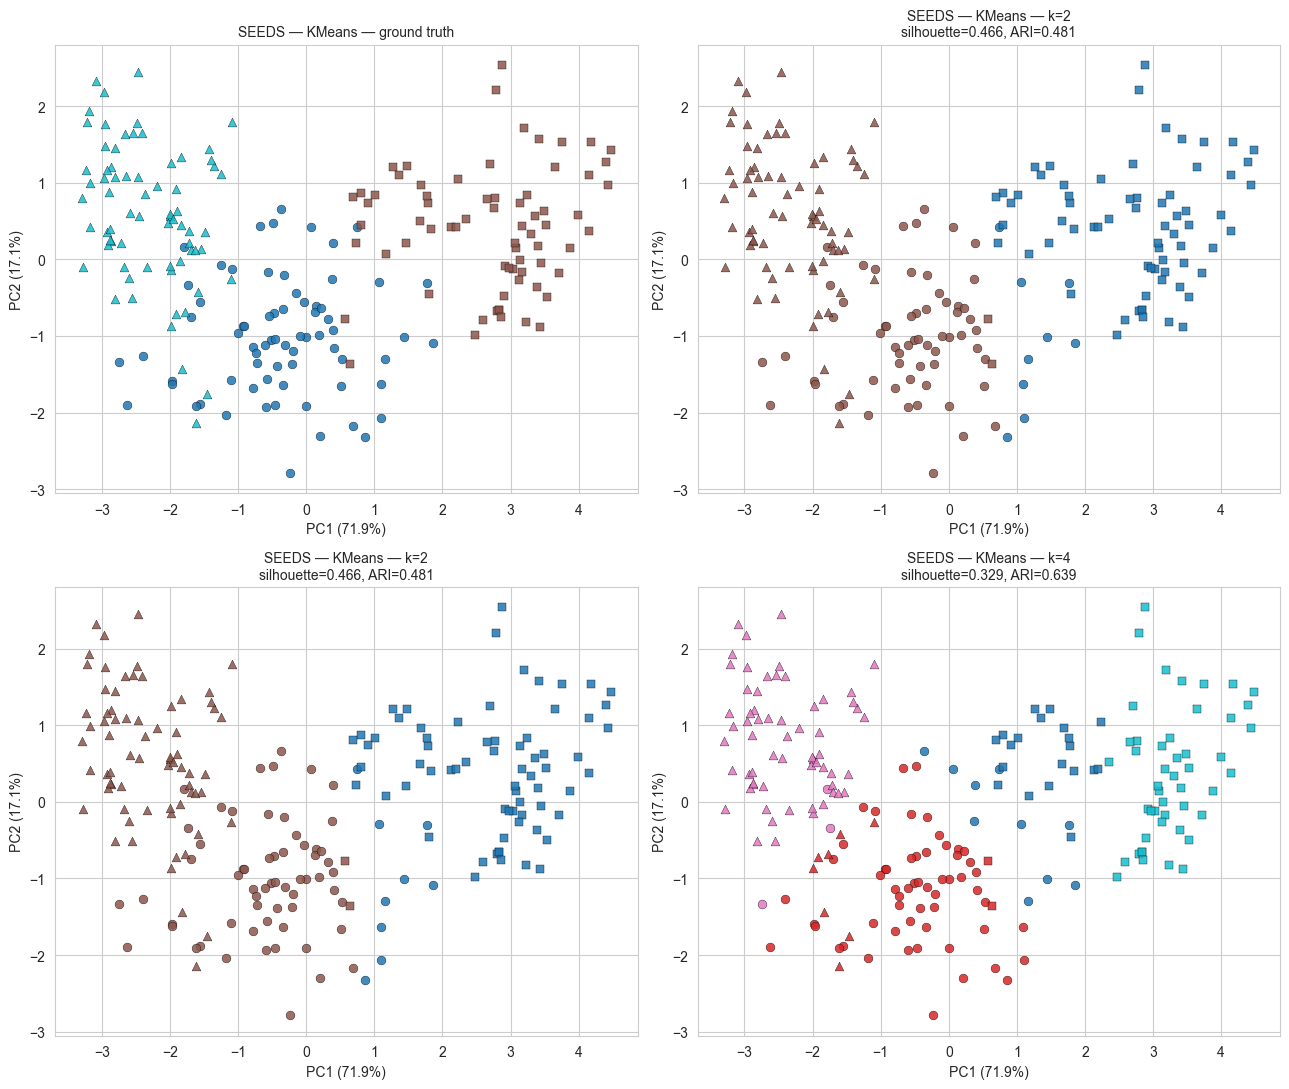

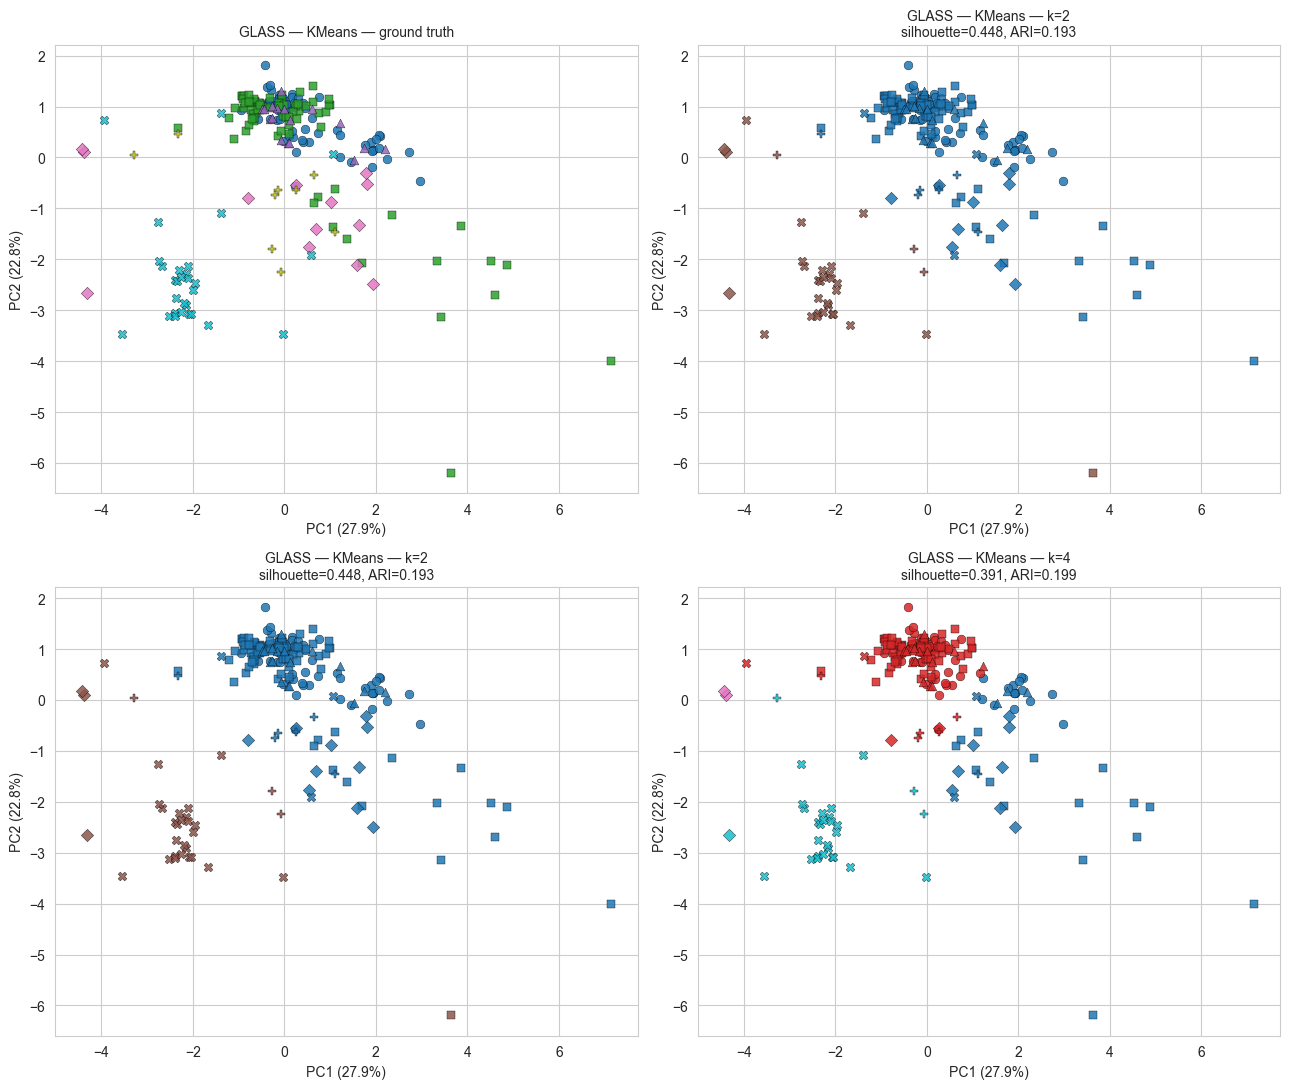

In [14]:
def four_panel_kmeans(X, y, k_best, title):
    pca = PCA(n_components=2).fit(X)
    ks = [max(2, k_best-1), k_best, k_best+2]
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    plot_clusters_pca(X, y, y, f'{title} — ground truth', ax=axes[0, 0], pca=pca)
    for ax, k in zip(axes.flatten()[1:], ks):
        km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(X)
        m = cluster_metrics(X, y, km.labels_)
        plot_clusters_pca(X, km.labels_, y,
                          f'{title} — k={k}\nsilhouette={m["silhouette"]:.3f}, ARI={m["ARI"]:.3f}',
                          ax=ax, pca=pca)
    plt.tight_layout(); plt.show()


four_panel_kmeans(X_seeds, y_seeds, k_best_seeds, 'SEEDS — KMeans')
four_panel_kmeans(X_glass, y_glass, k_best_glass, 'GLASS — KMeans')


## 5. DBSCAN — sweep hiperparametrów

Badamy `eps`, `min_samples`, `metric`. Zaczynamy od **k-distance plot** — klasycznej heurystyki doboru `eps` (knee na posortowanych odległościach do k-tego najbliższego sąsiada).


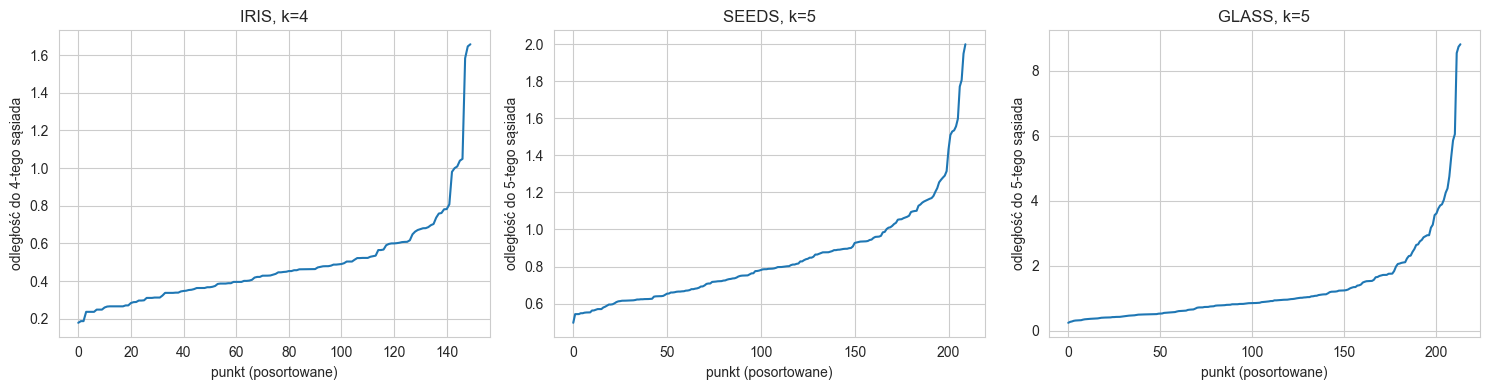

In [15]:
def kdist_plot(X, k, title, ax=None):
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    d, _ = nn.kneighbors(X)
    dk = np.sort(d[:, -1])
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(dk)
    ax.set_xlabel('punkt (posortowane)')
    ax.set_ylabel(f'odległość do {k}-tego sąsiada')
    ax.set_title(title)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kdist_plot(X_iris, 4, 'IRIS, k=4', ax=axes[0])
kdist_plot(X_seeds, 5, 'SEEDS, k=5', ax=axes[1])
kdist_plot(X_glass, 5, 'GLASS, k=5', ax=axes[2])
plt.tight_layout(); plt.show()


**Sanity check DBSCAN na IRIS** — dobieramy `eps` z knee (~1.0) i sprawdzamy:


In [16]:
db_iris = DBSCAN(eps=1.0, min_samples=4).fit(X_iris)
m = cluster_metrics(X_iris, y_iris, db_iris.labels_)
print('DBSCAN(eps=1.0, min_samples=4) na IRIS:')
display(pd.DataFrame([m]).round(4))


DBSCAN(eps=1.0, min_samples=4) na IRIS:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
0,2,3,0.5952,0.5714,0.5536,0.6733


DBSCAN znajduje na IRIS zwykle 2 klastry: setosa (gęsta, dobrze odseparowana) + reszta (versicolor + virginica zlewają się gęstościowo). To **fundamentalna różnica względem k-means** — DBSCAN nie zna „liczby klas”, znajduje to, co rzeczywiście jest gęste.


### 5.1 Sweep `eps`


In [17]:
def sweep_eps(X, y, eps_values, min_samples=5, metric='euclidean'):
    rows = []
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(X)
        m = cluster_metrics(X, y, db.labels_)
        m['eps'] = eps
        rows.append(m)
    return pd.DataFrame(rows).set_index('eps')


eps_grid_seeds = np.round(np.linspace(0.3, 2.5, 12), 3)
eps_grid_glass = np.round(np.linspace(0.3, 3.0, 12), 3)
res_seeds_eps = sweep_eps(X_seeds, y_seeds, eps_grid_seeds)
res_glass_eps = sweep_eps(X_glass, y_glass, eps_grid_glass)
print('SEEDS — sweep eps:'); display(res_seeds_eps.round(4))
print('GLASS — sweep eps:'); display(res_glass_eps.round(4))


SEEDS — sweep eps:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
eps,,,,,,
0.3000,0,210,NaN,NaN,0.0000,0.3333
0.5000,1,205,NaN,NaN,0.0019,0.3571
0.7000,7,78,0.3485,0.9655,0.3052,0.7524
0.9000,1,28,NaN,NaN,0.0041,0.3714
1.1000,1,9,NaN,NaN,-0.0005,0.3429
1.3000,1,4,NaN,NaN,0.0000,0.3429
1.5000,1,2,NaN,NaN,0.0002,0.3429
1.7000,1,0,NaN,NaN,0.0000,0.3333
1.9000,1,0,NaN,NaN,0.0000,0.3333


GLASS — sweep eps:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
eps,,,,,,
0.3000,1,207,NaN,NaN,-0.0080,0.3879
0.5450,1,153,NaN,NaN,-0.0215,0.3551
0.7910,4,103,0.4453,0.7044,0.0350,0.4065
1.0360,3,64,0.5795,0.5849,0.2126,0.4813
1.2820,3,47,0.5522,0.6415,0.2275,0.4907
1.5270,3,40,0.5310,0.6481,0.2273,0.4907
1.7730,3,28,0.4367,0.8075,0.2475,0.4860
2.0180,2,24,0.4951,0.7436,0.2039,0.4626
2.2640,1,21,NaN,NaN,0.0504,0.3598


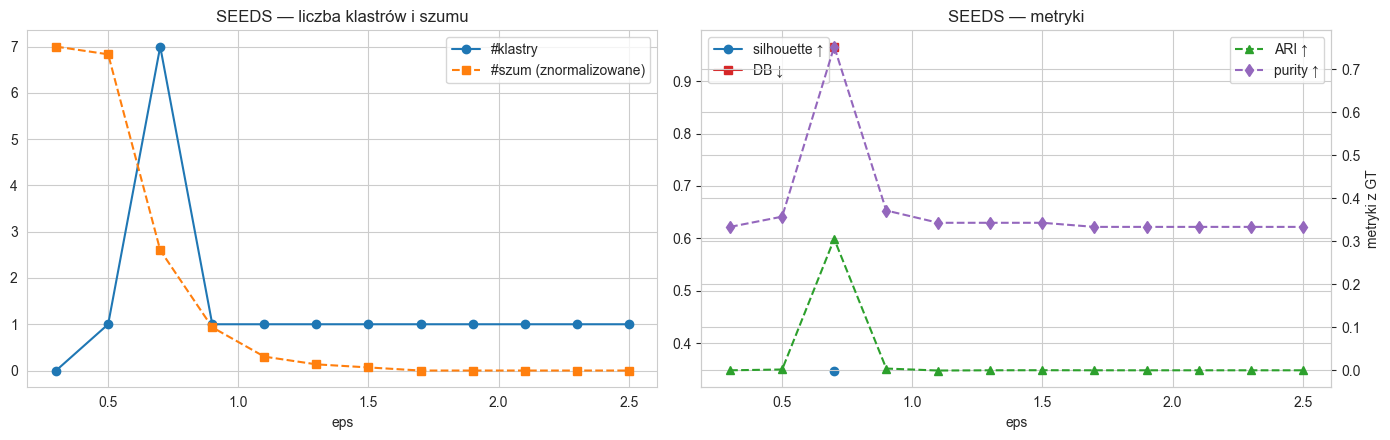

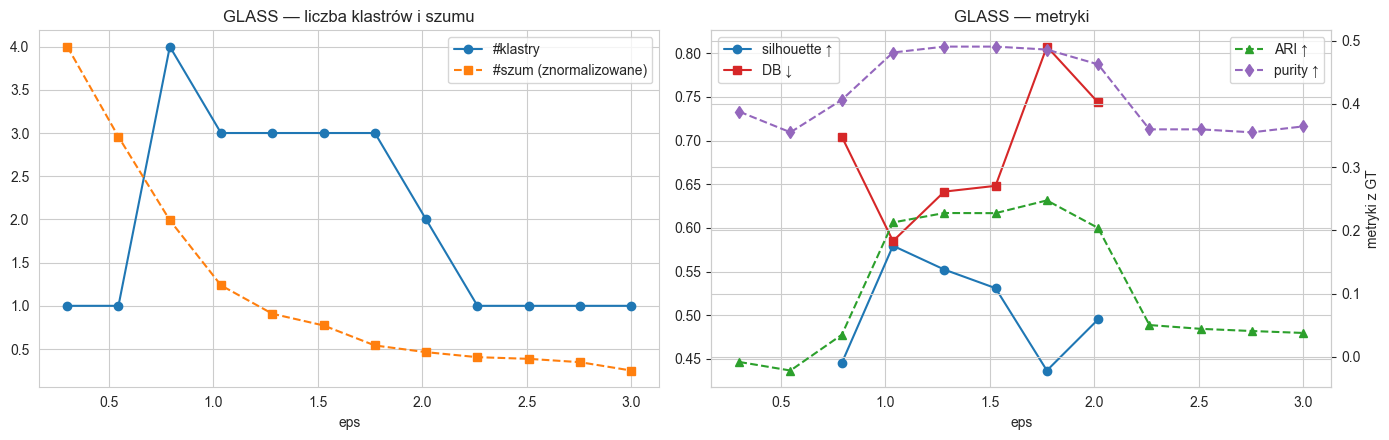

In [18]:
def plot_dbscan_sweep(df, x_name, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    ax = axes[0]
    ax.plot(df.index, df['n_clusters'], 'o-', label='#klastry')
    ax.plot(df.index, df['n_noise'] / df['n_noise'].max() * df['n_clusters'].max(),
            's--', label='#szum (znormalizowane)')
    ax.set_xlabel(x_name); ax.legend(); ax.set_title(f'{title} — liczba klastrów i szumu')

    ax = axes[1]
    ax.plot(df.index, df['silhouette'], 'o-', label='silhouette ↑', color='tab:blue')
    ax.plot(df.index, df['davies_bouldin'], 's-', label='DB ↓', color='tab:red')
    if 'ARI' in df.columns:
        ax2 = ax.twinx()
        ax2.plot(df.index, df['ARI'], '^--', label='ARI ↑', color='tab:green')
        ax2.plot(df.index, df['purity'], 'd--', label='purity ↑', color='tab:purple')
        ax2.set_ylabel('metryki z GT'); ax2.legend(loc='upper right')
    ax.set_xlabel(x_name); ax.legend(loc='upper left'); ax.set_title(f'{title} — metryki')
    plt.tight_layout(); plt.show()


plot_dbscan_sweep(res_seeds_eps, 'eps', 'SEEDS')
plot_dbscan_sweep(res_glass_eps, 'eps', 'GLASS')


**Obserwacje.** Dla małego `eps` praktycznie wszystko jest szumem (1–2 mikro-klastry). Dla dużego `eps` powstaje 1 gigantyczny klaster (silhouette / ARI = NaN lub 0). Optimum to wąski „środek”.


### 5.2 Sweep `min_samples`


eps_best:  SEEDS=0.7,  GLASS=1.036


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
min_samples,,,,,,
3,6,52,0.1767,0.8446,0.2722,0.6524
5,7,78,0.3485,0.9655,0.3052,0.7524
10,2,189,0.6454,0.4917,0.0147,0.4333
15,0,210,NaN,NaN,0.0000,0.3333
20,0,210,NaN,NaN,0.0000,0.3333


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
min_samples,,,,,,
3,5,53,0.2196,0.8127,0.2419,0.5093
5,3,64,0.5795,0.5849,0.2126,0.4813
10,2,90,0.4824,0.6630,0.1428,0.4112
15,1,113,NaN,NaN,0.0653,0.3598
20,1,132,NaN,NaN,0.0135,0.3598


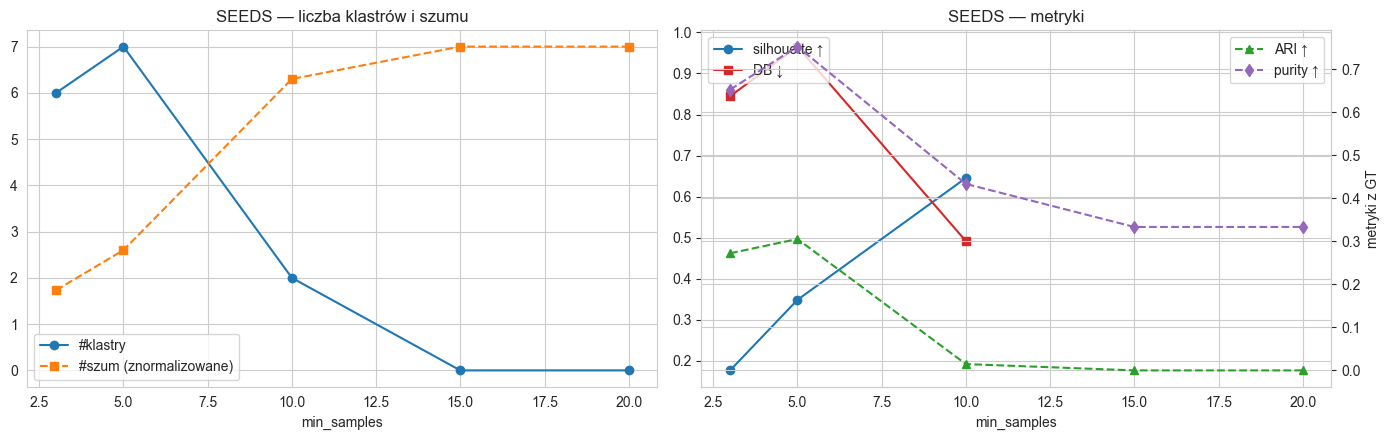

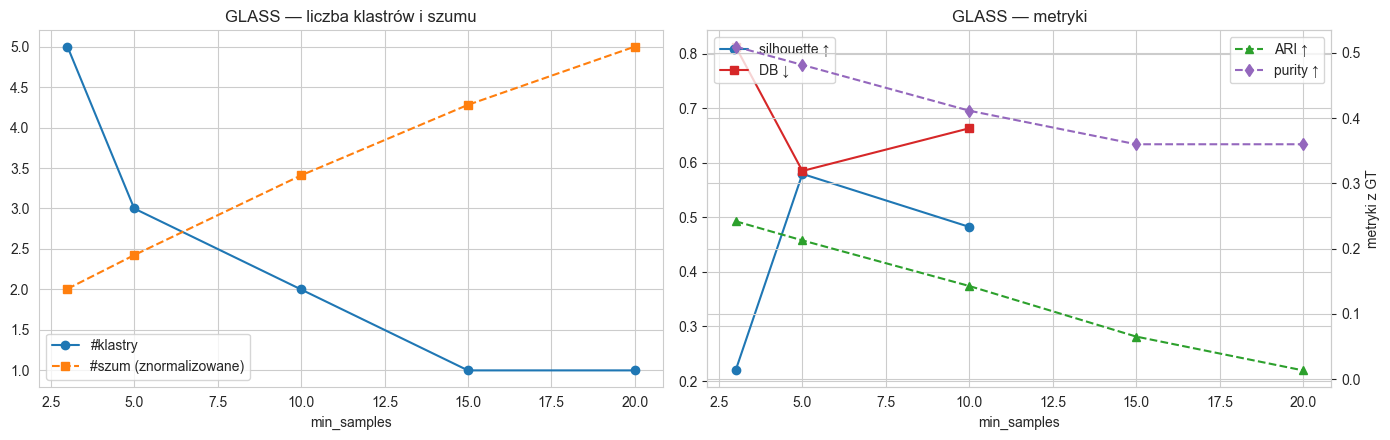

In [19]:
def sweep_min_samples(X, y, ms_values, eps, metric='euclidean'):
    rows = []
    for ms in ms_values:
        db = DBSCAN(eps=eps, min_samples=ms, metric=metric).fit(X)
        m = cluster_metrics(X, y, db.labels_)
        m['min_samples'] = ms
        rows.append(m)
    return pd.DataFrame(rows).set_index('min_samples')


ms_vals = [3, 5, 10, 15, 20]
# eps wybrany z poprzedniego sweepu — bierzemy najlepszy dla każdego zbioru
eps_best_seeds = float(res_seeds_eps['silhouette'].idxmax())
eps_best_glass = float(res_glass_eps['silhouette'].idxmax())
print(f'eps_best:  SEEDS={eps_best_seeds},  GLASS={eps_best_glass}')

res_seeds_ms = sweep_min_samples(X_seeds, y_seeds, ms_vals, eps=eps_best_seeds)
res_glass_ms = sweep_min_samples(X_glass, y_glass, ms_vals, eps=eps_best_glass)
display(res_seeds_ms.round(4))
display(res_glass_ms.round(4))
plot_dbscan_sweep(res_seeds_ms, 'min_samples', 'SEEDS')
plot_dbscan_sweep(res_glass_ms, 'min_samples', 'GLASS')


**Obserwacje.** Większe `min_samples` = bardziej restrykcyjna definicja „core” = więcej szumu i mniej (ale gęstszych) klastrów. Dla małych zbiorów (GLASS, 214 rek.) duże `min_samples` szybko niszczy klasteryzację.


### 5.3 Sweep `metric`


In [20]:
def sweep_metric(X, y, metrics, eps, min_samples=5):
    rows = []
    for met in metrics:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric=met).fit(X)
        m = cluster_metrics(X, y, db.labels_)
        m['metric'] = met
        rows.append(m)
    return pd.DataFrame(rows).set_index('metric')


metrics_list = ['euclidean', 'manhattan', 'chebyshev', 'cosine']
res_seeds_met = sweep_metric(X_seeds, y_seeds, metrics_list, eps=eps_best_seeds)
res_glass_met = sweep_metric(X_glass, y_glass, metrics_list, eps=eps_best_glass)
print('SEEDS — metric:'); display(res_seeds_met.round(4))
print('GLASS — metric:'); display(res_glass_met.round(4))


SEEDS — metric:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
metric,,,,,,
euclidean,7,78,0.3485,0.9655,0.3052,0.7524
manhattan,0,210,NaN,NaN,0.0000,0.3333
chebyshev,1,9,NaN,NaN,-0.0005,0.3429
cosine,1,0,NaN,NaN,0.0000,0.3333


GLASS — metric:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
metric,,,,,,
euclidean,3,64,0.5795,0.5849,0.2126,0.4813
manhattan,2,158,0.2621,1.4382,-0.0266,0.4346
chebyshev,3,35,0.5069,0.6349,0.2169,0.4579
cosine,1,0,NaN,NaN,0.0000,0.3551


**Komentarz.** Zmiana metryki zmienia skalę odległości (dla danych standaryzowanych: manhattan rośnie ~√d razy względem euklidesowej), więc to samo `eps` daje zupełnie inną klasteryzację. W praktyce `eps` należy dobrać **łącznie z metryką**.


## 6. Wizualizacja DBSCAN

Cztery panele: ground truth + 3 warianty `eps` (za małe / optymalne / za duże). Punkty szumu rysowane szarym X.


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_84013/1736904906.py:46: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Z[sel, 0], Z[sel, 1],
/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_84013/1736904906.py:46: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Z[sel, 0], Z[sel, 1],
/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_84013/1736904906.py:46: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Z[sel, 0], Z[sel, 1],


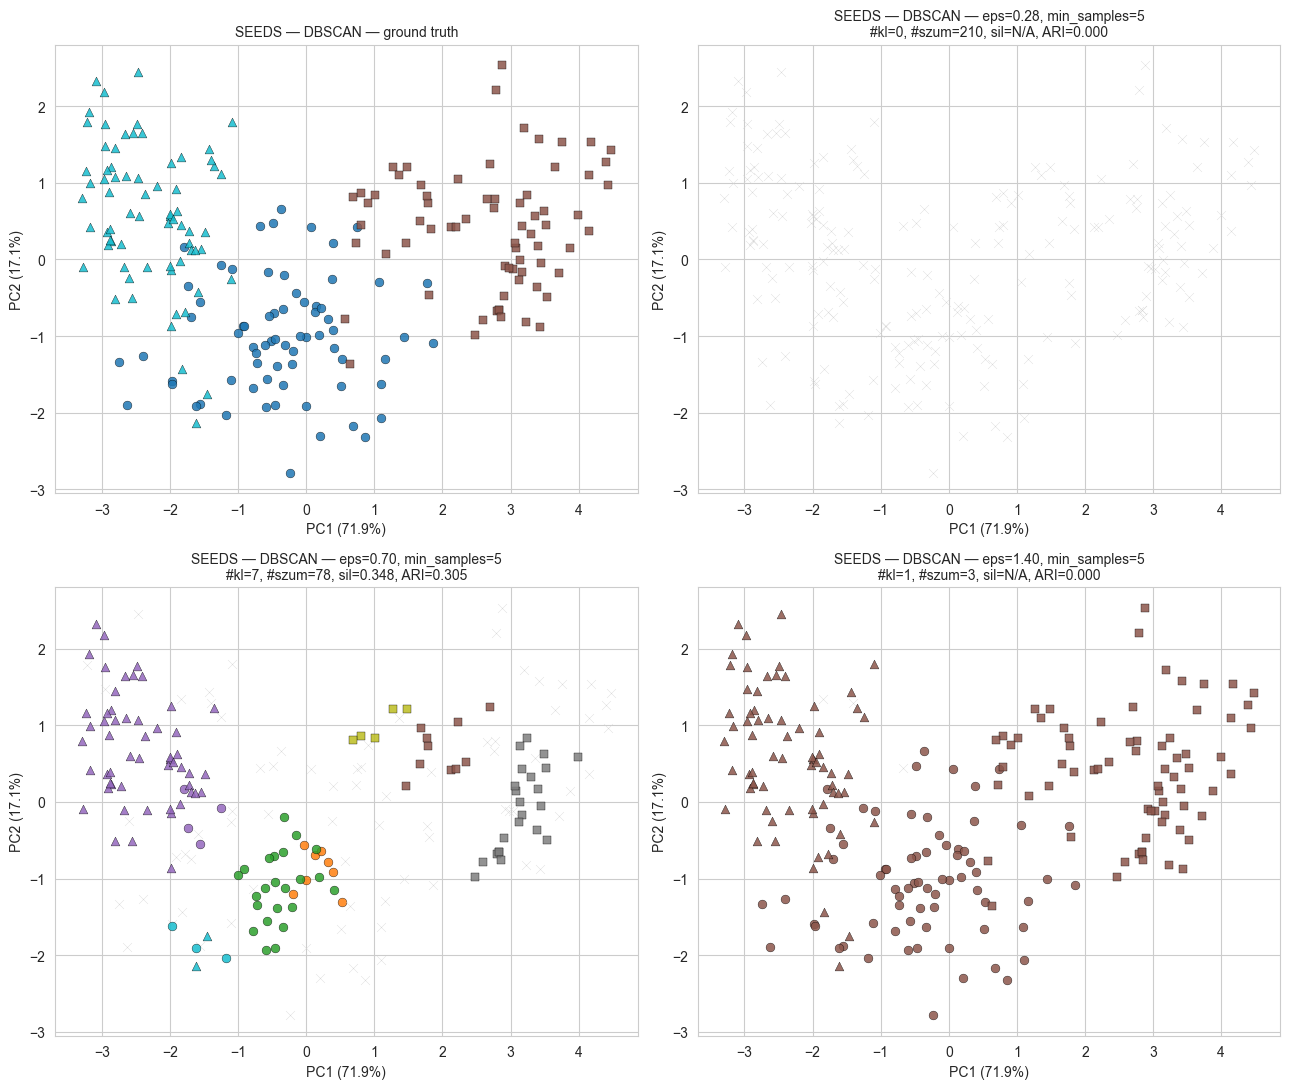

/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_84013/1736904906.py:46: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Z[sel, 0], Z[sel, 1],
/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_84013/1736904906.py:46: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Z[sel, 0], Z[sel, 1],
/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_84013/1736904906.py:46: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Z[sel, 0], Z[sel, 1],


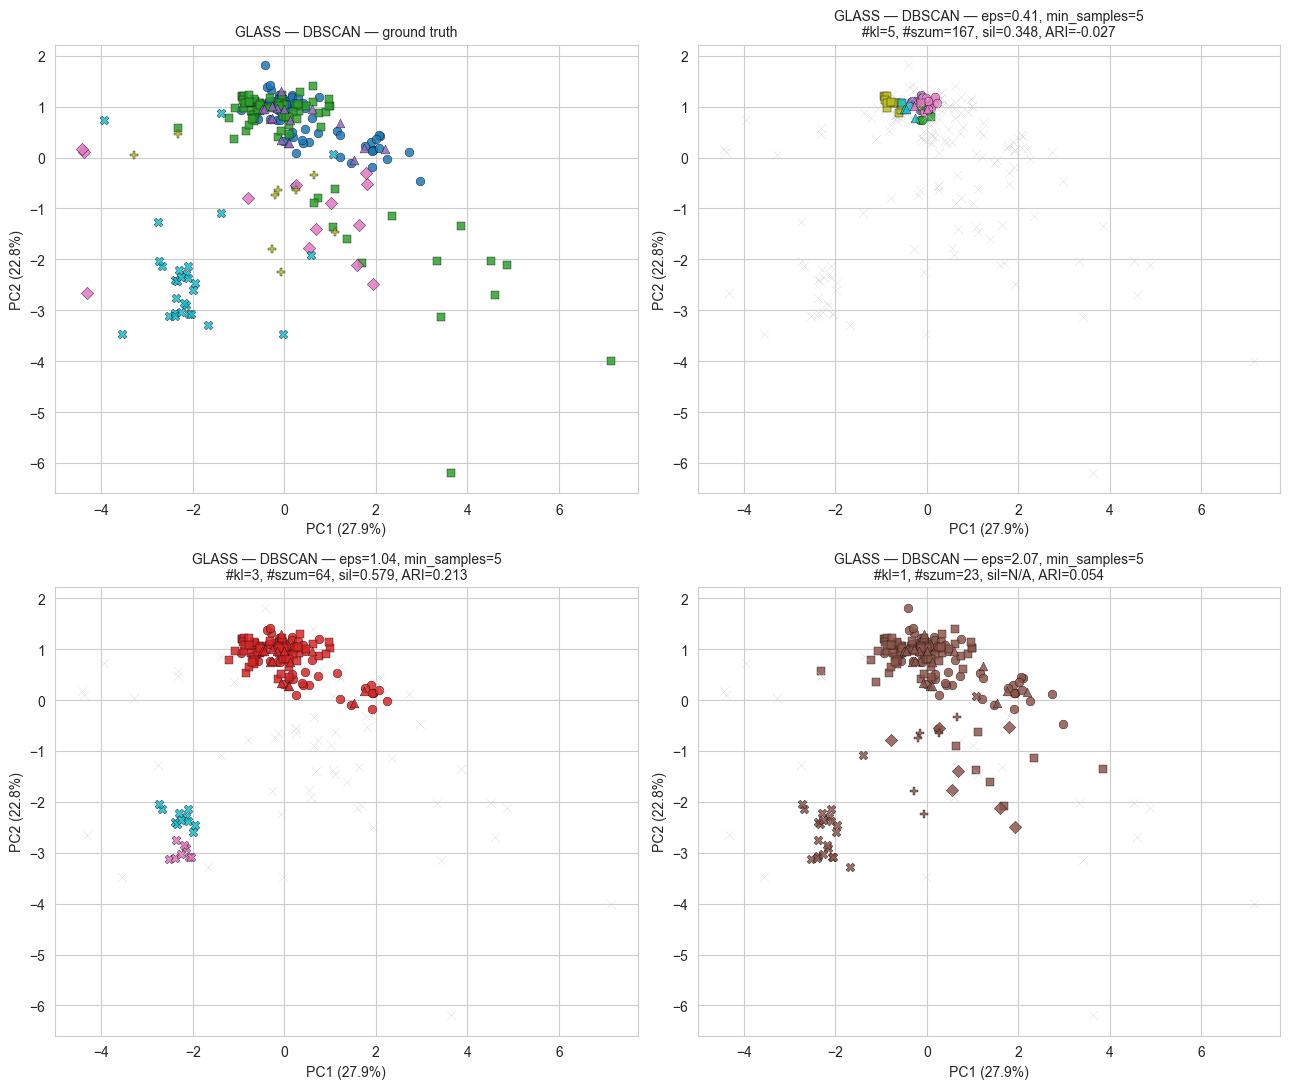

In [21]:
def four_panel_dbscan(X, y, eps_best, min_samples, title):
    pca = PCA(n_components=2).fit(X)
    eps_variants = [eps_best * 0.4, eps_best, eps_best * 2.0]
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    plot_clusters_pca(X, y, y, f'{title} — ground truth', ax=axes[0, 0], pca=pca)
    for ax, eps in zip(axes.flatten()[1:], eps_variants):
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        m = cluster_metrics(X, y, db.labels_)
        sil = f'{m["silhouette"]:.3f}' if not np.isnan(m['silhouette']) else 'N/A'
        plot_clusters_pca(X, db.labels_, y,
                          f'{title} — eps={eps:.2f}, min_samples={min_samples}\n#kl={m["n_clusters"]}, #szum={m["n_noise"]}, sil={sil}, ARI={m["ARI"]:.3f}',
                          ax=ax, pca=pca)
    plt.tight_layout(); plt.show()


four_panel_dbscan(X_seeds, y_seeds, eps_best_seeds, 5, 'SEEDS — DBSCAN')
four_panel_dbscan(X_glass, y_glass, eps_best_glass, 5, 'GLASS — DBSCAN')


## 7. Analiza porównawcza: k-means vs DBSCAN

Porównujemy najlepsze konfiguracje obu algorytmów na obu zbiorach. Wszystkie 4 metryki w jednej tabeli.


In [22]:
rows = []
# k-means best
for name, (X, y, _), k_best in [
    ('SEEDS', DATASETS['SEEDS'], k_best_seeds),
    ('GLASS', DATASETS['GLASS'], k_best_glass),
]:
    km = KMeans(n_clusters=k_best, n_init=20, random_state=0).fit(X)
    m = cluster_metrics(X, y, km.labels_)
    m.update({'dataset': name, 'algorytm': f'KMeans(k={k_best})'})
    rows.append(m)
# DBSCAN best
for name, (X, y, _), eps_best in [
    ('SEEDS', DATASETS['SEEDS'], eps_best_seeds),
    ('GLASS', DATASETS['GLASS'], eps_best_glass),
]:
    db = DBSCAN(eps=eps_best, min_samples=5).fit(X)
    m = cluster_metrics(X, y, db.labels_)
    m.update({'dataset': name, 'algorytm': f'DBSCAN(eps={eps_best:.2f})'})
    rows.append(m)

summary = pd.DataFrame(rows).set_index(['dataset', 'algorytm'])[
    ['n_clusters', 'n_noise', 'silhouette', 'davies_bouldin', 'ARI', 'purity']
]
display(summary.round(4))


,,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
dataset,algorytm,,,,,,
SEEDS,KMeans(k=2),2,0,0.4658,0.7969,0.4805,0.6571
GLASS,KMeans(k=2),2,0,0.4475,1.3783,0.1930,0.4720
SEEDS,DBSCAN(eps=0.70),7,78,0.3485,0.9655,0.3052,0.7524
GLASS,DBSCAN(eps=1.04),3,64,0.5795,0.5849,0.2126,0.4813


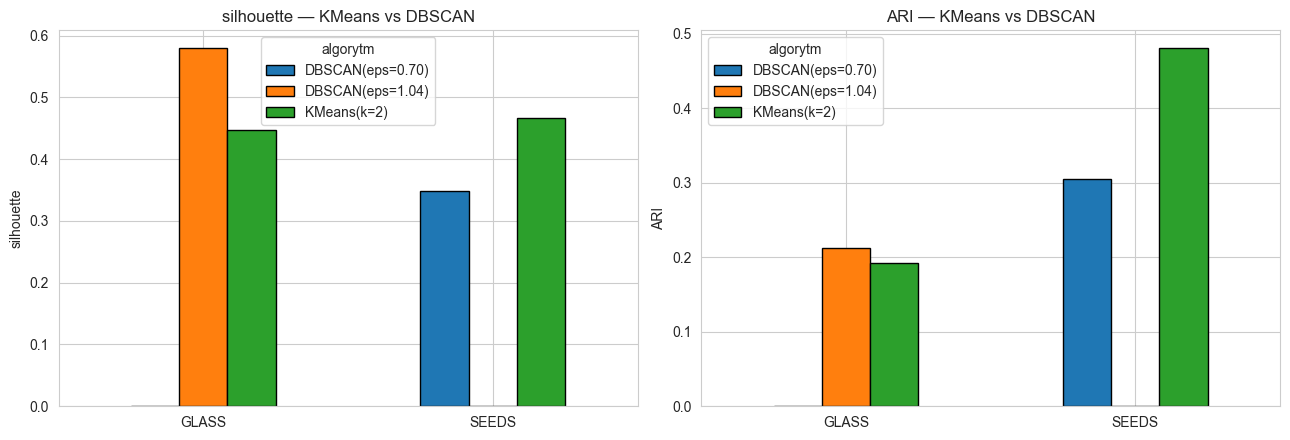

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, met in zip(axes, ['silhouette', 'ARI']):
    summary[met].unstack().plot(kind='bar', ax=ax, edgecolor='k')
    ax.set_title(f'{met} — KMeans vs DBSCAN')
    ax.set_xlabel(''); ax.set_ylabel(met)
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


## 8. Odpowiedzi na pytania pomocnicze z PDF

**1. Czy potrzebna jest normalizacja/standaryzacja?**
Tak — oba algorytmy są wrażliwe na skalę cech. k-means liczy odległości euklidesowe, DBSCAN buduje sąsiedztwa o stałym promieniu `eps`. Bez standaryzacji cecha o największym zakresie zdominuje odległość.

**2. Co różni oba algorytmy z punktu widzenia reprezentacji klastra? Konsekwencje dla predykcji?**
k-means reprezentuje klaster jako *centroid* (punkt w przestrzeni), więc predykcja na nowych danych = `argmin` odległości do centroidów (`KMeans.predict`).
DBSCAN nie ma jawnej reprezentacji klastra — opisuje go zbiorem punktów core + ich sąsiedztwami. Stąd brak prostego `predict` w sklearn; dla nowych punktów trzeba albo dokleić je heurystycznie do najbliższego core, albo przeklasteryzować cały zbiór.

**3. Który algorytm jest mniej odporny na szum/outliers?**
**k-means** — każdy punkt jest przypisany do jakiegoś klastra, outliers „ciągną” centroidy.
**DBSCAN** jest zaprojektowany pod szum: punkty bez odpowiedniej gęstości sąsiedztwa dostają etykietę -1 i nie wpływają na pozostałe klastry.

**4. Czy w grupowaniu używamy walidacji krzyżowej?**
Klasycznie **nie** — brak etykiet sprawia, że nie ma czego „walidować” w sensie nadzorowanym. CV ma sens tylko gdy traktujemy klasteryzację jako etap preprocessingu w pipeline z modelem nadzorowanym, albo gdy oceniamy stabilność (np. wariancja silhouette przy resampling).

**5. Czy wyniki powinny być powtarzane i uśredniane?**
**k-means** — tak, jest zależny od inicjalizacji centroidów (stąd `n_init`). Boxploty w sekcji 3.2 pokazują, że `n_init=1` daje duży rozrzut.
**DBSCAN** — wynik jest deterministyczny (dla ustalonych hiperparametrów i kolejności danych), więc powtarzanie nie redukuje wariancji — ale warto powtórzyć dla różnych podzbiorów danych, by ocenić stabilność.

**6. Co mierzą badane miary?**
- **Silhouette** ∈ [-1, 1] (max) — łączy spójność klastra i jego separację od najbliższego sąsiedniego klastra.
- **Davies–Bouldin** ∈ [0, ∞) (min) — średni stosunek „rozproszenia wewnątrz” do „odległości między” klastrami.
- **Adjusted Rand Index** ∈ [-1, 1] (max) — zgodność partycji z ground truth, skorygowana o losowość.
- **Purity** ∈ [0, 1] (max) — udział „dominującej klasy” w każdym klastrze. **Uwaga**: trywialnie = 1 gdy każdy punkt to osobny klaster — niewrażliwa na liczbę klastrów.

**7. Czy liczba klastrów musi odpowiadać liczbie klas?**
Nie. Klasteryzacja jest nienadzorowana — wybór `k` powinien wynikać z **celu analizy** lub z miar bez etykiet (silhouette, DB, elbow). Jeśli klasy nie tworzą zwartych skupisk geometrycznych (jak na GLASS), to nawet k = #klas nie da wysokiego ARI.


## 9. TL;DR

- **SEEDS** to zbiór „wdzięczny”: k-means z k=3 odzyskuje klasy z ARI ≈ 0.7–0.8. DBSCAN po dobrym doborze `eps` dorównuje.
- **GLASS** jest geometrycznie trudny: klasy chemiczne nie pokrywają się ze skupiskami w przestrzeni cech. Silhouette wybiera k=2; ARI niskie dla obu algorytmów.
- **Silhouette i Davies-Bouldin** (bez GT) potrafią rozjeżdżać się z **ARI/purity** (z GT) — to nie błąd, tylko sygnał że „naturalne” klastry ≠ etykiety.
- **k-means** wymaga znajomości `k`, jest wrażliwy na inicjalizację (używaj `n_init ≥ 10`) i outliers; szybko zbiega.
- **DBSCAN** sam decyduje o liczbie klastrów i odrzuca szum, ale wymaga starannego doboru `eps` (k-distance plot) i jest wrażliwy na wybór metryki + skalowanie cech.
